# MLP Dengue predict

In [18]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Load dataset

In [3]:
data = pd.read_csv('/content/drive/MyDrive/DENGUE/databases/dataset.csv', low_memory=True)
data.head()

,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome
0,Female,45,0,0,0,Mirpur,Undeveloped,Building,Dhaka,2,36.9,278586,5806,Severe,0,0,1,0,0
1,Male,17,0,0,1,Chawkbazar,Developed,Building,Dhaka,1,36.5,190699,7690,NaN,1,0,0,0,0
2,Female,29,0,0,0,Paltan,Undeveloped,Other,Dhaka,1,36.6,208973,6928,NaN,0,0,0,0,0
3,Female,63,1,1,0,Motijheel,Developed,Other,Dhaka,7,38.9,94336,3193,Moderate,0,0,1,0,1
4,Male,22,0,0,0,Gendaria,Undeveloped,Building,Dhaka,1,37.0,288202,7768,NaN,0,0,0,0,0


### To separate data from target

In [4]:
x = data.drop(columns=['Gender', 'Area', 'AreaType', 'HouseType',
                       'District', 'Outcome'])
y = data['Outcome']

In [5]:
for col in x.columns:
  print(x.value_counts(col))
  print("")
print(y.value_counts())

Age
29    24
40    24
50    24
44    24
45    24
39    23
10    23
17    23
62    22
31    22
53    20
46    20
9     20
13    19
37    19
35    19
47    19
52    19
22    18
18    18
38    18
49    18
14    18
11    18
16    18
26    17
61    17
8     17
19    17
20    17
28    17
54    17
51    17
34    16
15    16
27    16
65    16
55    16
42    16
24    16
32    15
30    15
48    15
64    15
25    14
21    14
23    14
33    14
41    14
58    13
57    13
43    13
56    13
36    12
60    12
12    11
59    11
63    10
Name: count, dtype: int64

NS1
1    519
0    481
Name: count, dtype: int64

IgG
1    533
0    467
Name: count, dtype: int64

IgM
0    525
1    475
Name: count, dtype: int64

Fever_Duration
0    234
3    143
1    136
6    117
7    105
5     99
4     97
2     69
Name: count, dtype: int64

Body_Temperature
37.0    75
36.8    65
39.2    62
36.9    57
39.5    54
39.3    51
36.7    45
39.4    43
39.6    43
39.1    42
39.0    41
37.2    37
38.9    37
37.1    37
36.6    35
39.7

### To separate train from test

### Normalize atributes

In [6]:
scaler = StandardScaler()
x_columns_to_normalize = x.drop(columns=['Headache', 'Retro_Orbital_Pain', 'NS1',
                                      'IgG', 'IgM', 'Myalgia', 'Rash', 'Joint_Pain'])

original_column_names = x_columns_to_normalize.columns

x_columns_normalize = scaler.fit_transform(x_columns_to_normalize)
x_columns_normalize = pd.DataFrame(x_columns_normalize, columns=original_column_names)
x_columns_normalize.head()

,Age,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count
0,0.551391,-0.419584,-1.023908,1.402856,0.525495
1,-1.149682,-0.829735,-1.343230,0.431046,1.418066
2,-0.420651,-0.829735,-1.263399,0.633111,1.057058
3,1.644937,1.631169,0.572705,-0.634487,-0.712450
4,-0.845919,-0.829735,-0.944077,1.509185,1.455020


In [7]:
non_normalized_cols = ['Headache', 'Retro_Orbital_Pain', 'NS1', 'IgG', 'IgM', 'Myalgia', 'Rash', 'Joint_Pain']

x_categorical = x[non_normalized_cols]

x = pd.concat([x_categorical, x_columns_normalize], axis=1)
x.head()

,Headache,Retro_Orbital_Pain,NS1,IgG,IgM,Myalgia,Rash,Joint_Pain,Age,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count
0,0,0,0,0,0,1,0,Severe,0.551391,-0.419584,-1.023908,1.402856,0.525495
1,1,0,0,0,1,0,0,NaN,-1.149682,-0.829735,-1.343230,0.431046,1.418066
2,0,0,0,0,0,0,0,NaN,-0.420651,-0.829735,-1.263399,0.633111,1.057058
3,0,0,1,1,0,1,0,Moderate,1.644937,1.631169,0.572705,-0.634487,-0.712450
4,0,0,0,0,0,0,0,NaN,-0.845919,-0.829735,-0.944077,1.509185,1.455020


In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Headache            1000 non-null   int64  
 1   Retro_Orbital_Pain  1000 non-null   int64  
 2   NS1                 1000 non-null   int64  
 3   IgG                 1000 non-null   int64  
 4   IgM                 1000 non-null   int64  
 5   Myalgia             1000 non-null   int64  
 6   Rash                1000 non-null   int64  
 7   Joint_Pain          509 non-null    object 
 8   Age                 1000 non-null   float64
 9   Fever_Duration      1000 non-null   float64
 10  Body_Temperature    1000 non-null   float64
 11  Platelet_Count      1000 non-null   float64
 12  WBC_Count           1000 non-null   float64
dtypes: float64(5), int64(7), object(1)
memory usage: 101.7+ KB


### Create columns severe, moderate and no_severe_moderate

In [9]:
x['Severe'] = x['Joint_Pain'].apply(lambda x: 1 if x == 'Severe' else 0)
x['Moderate'] = x['Joint_Pain'].apply(lambda x: 1 if x == 'Moderate' else 0)
x['No_Severe_Moderate'] = x['Joint_Pain'].apply(lambda x: 0 if x != 'Severe' and x != 'Moderate'  else 1)
x.head()

,Headache,Retro_Orbital_Pain,NS1,IgG,IgM,Myalgia,Rash,Joint_Pain,Age,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count,Severe,Moderate,No_Severe_Moderate
0,0,0,0,0,0,1,0,Severe,0.551391,-0.419584,-1.023908,1.402856,0.525495,1,0,1
1,1,0,0,0,1,0,0,NaN,-1.149682,-0.829735,-1.343230,0.431046,1.418066,0,0,0
2,0,0,0,0,0,0,0,NaN,-0.420651,-0.829735,-1.263399,0.633111,1.057058,0,0,0
3,0,0,1,1,0,1,0,Moderate,1.644937,1.631169,0.572705,-0.634487,-0.712450,0,1,1
4,0,0,0,0,0,0,0,NaN,-0.845919,-0.829735,-0.944077,1.509185,1.455020,0,0,0


In [10]:
y = x['No_Severe_Moderate']
x = x.drop(columns=['Joint_Pain', 'NS1', 'IgG', 'IgM', 'Severe', 'Moderate', 'No_Severe_Moderate', 'Age'])
x.head()

,Headache,Retro_Orbital_Pain,Myalgia,Rash,Fever_Duration,Body_Temperature,Platelet_Count,WBC_Count
0,0,0,1,0,-0.419584,-1.023908,1.402856,0.525495
1,1,0,0,0,-0.829735,-1.343230,0.431046,1.418066
2,0,0,0,0,-0.829735,-1.263399,0.633111,1.057058
3,0,0,1,0,1.631169,0.572705,-0.634487,-0.712450
4,0,0,0,0,-0.829735,-0.944077,1.509185,1.455020


In [11]:
x.columns

Index(['Headache', 'Retro_Orbital_Pain', 'Myalgia', 'Rash', 'Fever_Duration',
       'Body_Temperature', 'Platelet_Count', 'WBC_Count'],
      dtype='object')

In [12]:
y.head()

,No_Severe_Moderate
0,1
1,0
2,0
3,1
4,0


In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
import torch.nn as nn

class MLPregression(nn.Module):
    def __init__(self, input_size):
        super(MLPregression, self).__init__()
        self.input = nn.Linear(input_size, 64)
        self.hidden = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden(x))

        x = self.sigmoid(self.output(x))
        return x


In [15]:
x_train = torch.tensor(x_train.values, dtype = torch.float32)
x_test = torch.tensor(x_test.values, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype = torch.float32).unsqueeze(1)

In [16]:
model = MLPregression(input_size=x_train.shape[1])
criterion = nn.BCELoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=0.001)

epocs = 2000
train_loss = np.zeros(epocs)

for epoch in range(epocs):
    model.train()
    optimizer.zero_grad()

    outputs = model(x_train)
    pesos = torch.where(y_train == 1, 15.0, 1.0)

    element_wise_loss = criterion(outputs, y_train)

    weighted_loss = element_wise_loss * pesos
    loss = torch.mean(weighted_loss)

    loss.backward()

    optimizer.step()
    train_loss[epoch] = loss.item()

=== RESULTADOS DA AVALIAÇÃO NO CONJUNTO DE TESTE ===
Acurácia (Acertos totais) : 0.8350 (83.50%)
Precisão (Qualidade dos alarmes) : 0.8047
Recall   (Capacidade de achar os positivos) : 0.9279
F1-Score (Equilíbrio Precisão/Recall) : 0.8619



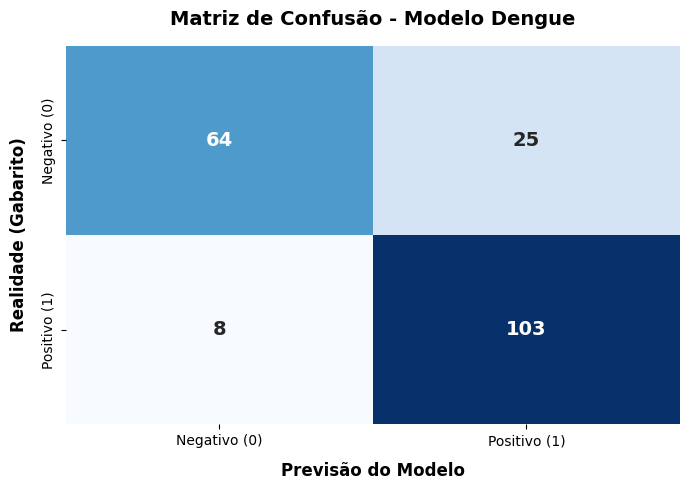

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model.eval()

with torch.no_grad():
    test_outputs = model(x_test)

    previsoes = (test_outputs > 0.5).float()

y_true = y_test.numpy()
y_pred = previsoes.numpy()


acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("=== RESULTADOS DA AVALIAÇÃO NO CONJUNTO DE TESTE ===")
print(f"Acurácia (Acertos totais) : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precisão (Qualidade dos alarmes) : {prec:.4f}")
print(f"Recall   (Capacidade de achar os positivos) : {rec:.4f}")
print(f"F1-Score (Equilíbrio Precisão/Recall) : {f1:.4f}\n")


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])

plt.title('Matriz de Confusão - Modelo Dengue', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Realidade (Gabarito)', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()